In [1]:
import pandas as pd
import torch
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np


In [2]:
def load_and_process_results(path):
    df = pd.read_json(path, orient="records", lines=True)
    df = pd.json_normalize(df.to_dict(orient="records"))

    # Add a "checkpoint" column based on a regex search in the "model" field
    df["checkpoint"] = df["model"].str.extract(r'checkpoint-(\d+)', expand=False).fillna(0).astype(int)
    df["short_model"] = df["model"].str.extract(r'output/(.*)/checkpoint-(\d+)', expand=False)[0]
    df["short_dataset"] = df["dataset"].str.split('/').str[1]
    # remove all json prefixes from column names (e.g. foo.bar.baz -> baz, evaluation_scores.ndcg@10 -> ndcg@10)
    df.drop(columns=["index_config.init_kwargs.name", "index_config.init_kwargs.index_name"], inplace=True)
    df.columns = df.columns.str.split('.').str[-1]

    return df

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

def plot_checkpoint_vs_metrics(df, model_prefixes, metrics, dataset_col='dataset'):
    """
    Plot checkpoint vs metric for multiple models across datasets and metrics,
    only for datasets that are present for at least one of the models in model_prefixes.
    Legend appears only once outside the superplot.
    Ensure that the legend has one unique entry per model prefix actually present in the plot,
    to avoid duplicate lines/labels if a model isn't present in every subplot.
    """
    # Filter df for only the relevant model_prefixes
    mask = np.zeros(len(df), dtype=bool)
    for model_prefix in model_prefixes:
        mask |= df['model'].str.contains(model_prefix, na=False)
    filtered_df = df[mask].copy()
    
    # Get unique datasets that appear in the filtered df
    datasets = sorted(filtered_df[dataset_col].unique())
    n_datasets = len(datasets)
    n_metrics = len(metrics)
    
    # Create figure with subplots: rows = datasets, cols = metrics
    fig, axes = plt.subplots(
        n_datasets, n_metrics, 
        figsize=(5 * n_metrics + 2, 4 * n_datasets + 2),  # make slightly larger
        squeeze=False
    )

    # Add whitespace between subplots for clarity
    fig.subplots_adjust(
        left=0.07, right=0.98, top=0.90, bottom=0.08,
        hspace=0.3, wspace=0.3  # more space between plots both vertically and horizontally
    )
    
    # Color palette for different models
    colors = plt.cm.tab10(np.linspace(0, 1, len(model_prefixes)))
    
    # To ensure each model line gets only one label, 
    # we track lines and labels based on actual plotting.
    handles_for_legend = {}
    
    # Plot each dataset x metric combination
    for i, dataset in enumerate(datasets):
        for j, metric in enumerate(metrics):
            ax = axes[i, j]
            
            # Plot each model
            for model_idx, model_prefix in enumerate(model_prefixes):
                # Filter data for this model and dataset
                model_mask = (filtered_df['model'].str.contains(model_prefix, na=False)) & \
                             (filtered_df[dataset_col] == dataset)
                model_data = filtered_df[model_mask].copy()
                
                if len(model_data) > 0:
                    # Convert checkpoint to numeric and sort
                    model_data['checkpoint'] = pd.to_numeric(model_data['checkpoint'], errors='coerce')
                    model_data = model_data.dropna(subset=['checkpoint', metric])
                    model_data = model_data.sort_values('checkpoint')
                    
                    # Plot line
                    line, = ax.plot(model_data['checkpoint'], model_data[metric],
                                    marker='o', label=model_prefix, color=colors[model_idx],
                                    linewidth=2, markersize=6)
                    # For legend: Only collect the first instance of each model_prefix
                    if model_prefix not in handles_for_legend and len(model_data) > 0:
                        handles_for_legend[model_prefix] = line
            
            # Set labels and title
            ax.set_xlabel('Checkpoint', fontsize=10)
            ax.set_ylabel(metric, fontsize=10)
            ax.set_title(f'{dataset} - {metric}', fontsize=11, fontweight='bold')
            ax.grid(True, alpha=0.3)
            # Remove per-axes legend
            # ax.legend(fontsize=8)
    
    # Add a single legend for all subplots, outside the superplot
    if handles_for_legend:
        fig.legend(
            list(handles_for_legend.values()), 
            list(handles_for_legend.keys()), 
            loc='upper center',
            fontsize=10,
            ncol=2, 
        )
    return fig


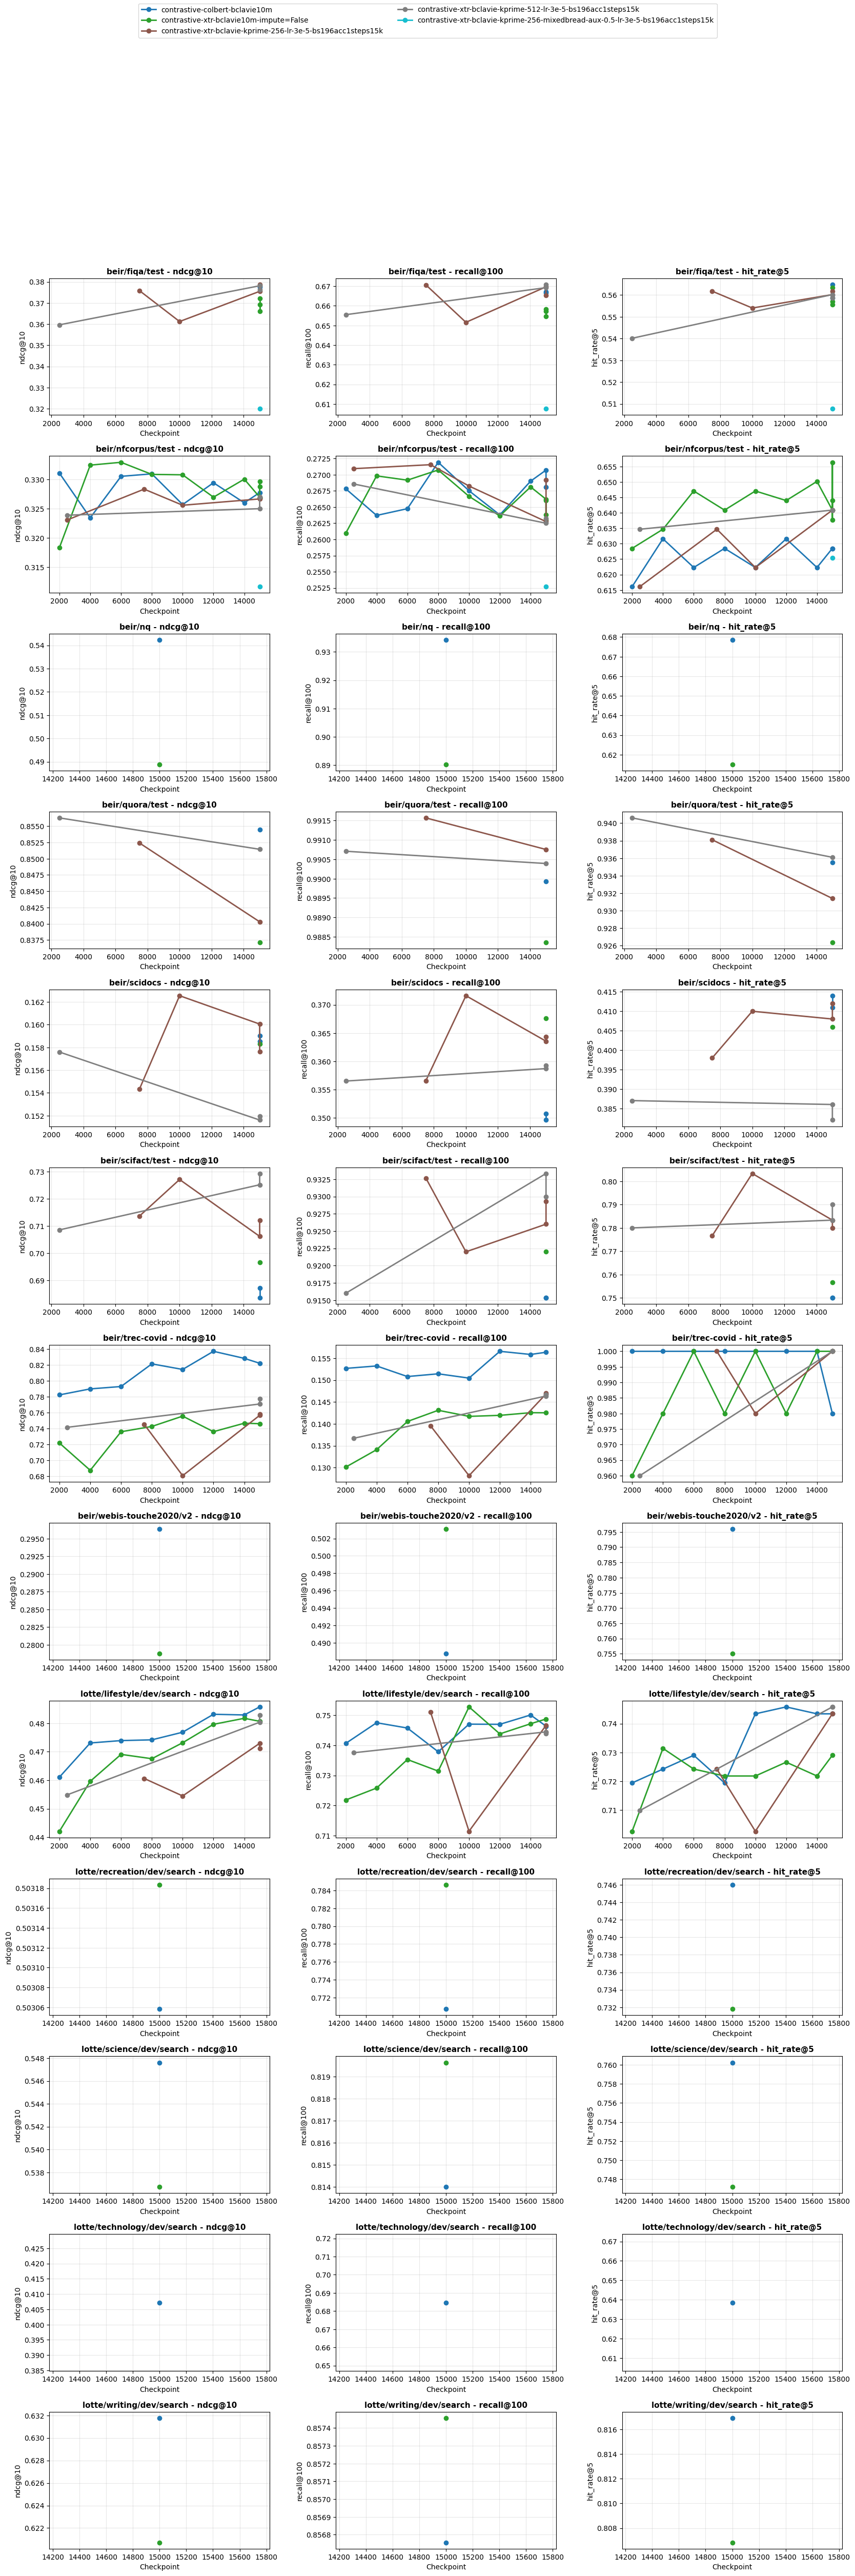

In [8]:
df = load_and_process_results("/home/hltcoe/rjha/rjha_exp/pylate-xtr/results/all_results.jsonl")
contrastive_models = [
    "contrastive-colbert-bclavie10m",
    # "contrastive-xtr-bclavie10m-impute=True",
    "contrastive-xtr-bclavie10m-impute=False",
    "contrastive-xtr-bclavie-kprime-256-lr-3e-5-bs196acc1steps15k",
    "contrastive-xtr-bclavie-kprime-512-lr-3e-5-bs196acc1steps15k",
    "contrastive-xtr-bclavie-kprime-256-mixedbread-aux-0.5-lr-3e-5-bs196acc1steps15k",
]
kd_models = [
    "kd-colbert-gte-mbert-bs24acc1nway16-minmax-False-gemma-unnormalized",
    "kd-xtr-gte-mbert-Z-True-bs24acc1nway16-minmax-False-gemma-unnormalized",
    "kd-xtr-gte-mbert-Z-False-bs24acc1nway16-minmax-False-gemma-unnormalized",
    "kd-xtr-gte-mbert-Z-False-kprime-64-bs24acc1nways16-minmax-False-gemma-unnormalized",
    "kd-xtr-gte-mbert-Z-False-kprime-256-bs24acc1nways16-minmax-False-gemma-unnormalized",
]
base_models = [
    # "robro612/xtr-base-en-pylate",
]

model_prefixes = contrastive_models

filtered_df = df[df['model'].apply(lambda x: any(prefix in str(x) for prefix in model_prefixes))]


metrics = ['ndcg@10', 'recall@100', 'hit_rate@5']
fig = plot_checkpoint_vs_metrics(filtered_df, model_prefixes, metrics)
plt.show()

In [ ]:
df = load_and_process_results("/home/hltcoe/rjha/rjha_exp/pylate-xtr/results/all_results.jsonl")
model_prefixes = {
    # "contrastive-xtr-bclavie10m-impute=True" : "xtr-impute",
    "contrastive-xtr-bclavie10m-impute=False" : "contrastive-xtr",
    # "kd-xtr-gte-mbert-Z-True-bs12acc1" : "kd-xtr-Z",
    "contrastive-colbert-bclavie10m" : "contrastive-colbert",
    "kd-colbert-gte-mbert-bs24acc1nway16-minmax-False-gemma-unnormalized" : "kd-colbert",
    "kd-xtr-gte-mbert-Z-False-bs24acc1nway16-minmax-False-gemma-unnormalized" : "kd-xtr-gemma-unnorm-no-Z",
    # "kd-xtr-gte-mbert-Z-False-bs16acc1nway16-minmax-False-gemma-unnormalized" : "kd-xtr-gemma-unnorm-no-Z-nway16",
    "robro612/xtr-base-en-pylate" : "xtr-sota",
}

filtered_df = df[df['model'].apply(lambda x: any(prefix in str(x) for prefix in model_prefixes))]
filtered_df["checkpoint"] = filtered_df["model"].str.extract(r'checkpoint-(\d+)').fillna("0").astype(int)
# Keep only rows whose model contains one of the model_prefixes keys, and for each such group, keep the highest checkpoint
filtered_df = filtered_df[
    filtered_df["model"].apply(lambda x: any(prefix in str(x) for prefix in model_prefixes))
]
# get the highest checkpoint for each model/dataset combo
filtered_df = filtered_df.loc[filtered_df.groupby(['model', 'dataset'])['checkpoint'].idxmax()]
# get the second element in the /-joined string as the short_dataset
filtered_df["short_dataset"] = filtered_df["dataset"].str.split('/').str[1]

# List of metrics to plot
metrics = ['ndcg@10', 'recall@100', 'hit_rate@5']
datasets = ['nfcorpus', 'trec-covid', "fiqa", "scidocs", "scifact", "quora", "webis-touche2020","lifestyle", "recreation", "writing", "science"]
# make a new model column that strips everything before (and including) output/ and after (including) /checkpoint
filtered_df["short_model"] = filtered_df["model"].str.extract(r'output/(.*)/checkpoint-(\d+)')[0].fillna(filtered_df["model"])

def plot_bar_chart(df, short_datasets, metrics, model_col="short_model", dataset_col="short_dataset"):
    D = len(short_datasets)
    M = len(metrics)
    model_names = df[model_col].unique()
    fig, axes = plt.subplots(D, M, figsize=(3*M, 3*D), squeeze=False)
    bar_handles = []
    for d_idx, dataset in enumerate(short_datasets):
        for m_idx, metric in enumerate(metrics):
            ax = axes[d_idx, m_idx]
            df_plot = df[df[dataset_col] == dataset]
            values = []
            for model in model_names:
                val = df_plot[df_plot[model_col] == model][metric]
                if not val.empty:
                    values.append(val.values[0])
                else:
                    values.append(float('nan'))
            bars = ax.bar(model_names, values, color=sns.color_palette("pastel", len(model_names)))
            # Label each bar with its value
            for bar, value in zip(bars, values):
                # Only label if value is not nan
                if not (isinstance(value, float) and np.isnan(value)):
                    height = bar.get_height()
                    ax.annotate(f"{height:.3f}", 
                                xy=(bar.get_x() + bar.get_width() / 2, height),
                                xytext=(0, -10),  # Vertical offset above bar
                                textcoords="offset points",
                                ha='center', va='bottom', fontsize=8)
            # Only collect handles for the first axis
            if d_idx == 0 and m_idx == 0:
                bar_handles = bars
            ax.set_title(f"{dataset} - {metric}")
            # no x labels
            ax.set_xticklabels([])
    # Add a single legend outside the whole plot
    fig.legend(bar_handles, model_names, title="Model", loc='center left', bbox_to_anchor=(1.01, 0.5))
    fig.tight_layout(rect=[0, 0, 1, 1])  # leave space for legend

    
plot_bar_chart(filtered_df, datasets, metrics)

## All Results

In [ ]:
df = load_and_process_results("/home/hltcoe/rjha/rjha_exp/pylate-xtr/results/all_results.jsonl")
df["short_model"] = df["model"].str.extract(r'output/(.*)/checkpoint-(\d+)', expand=False)[0]
df["short_model"] = df["short_model"].fillna(df["model"])
df["short_dataset"] = df["dataset"].str.split('/').str[1]
df["checkpoint"] = df["model"].str.extract(r'checkpoint-(\d+)').fillna(0).astype(int)
df.set_index(["short_dataset", "short_model", "checkpoint"], inplace=True)
df = df.sort_values(["ndcg@10", "recall@100", "hit_rate@5"], ascending=False).sort_index()
df[["ndcg@10", "recall@100", "hit_rate@5"]] = (df[["ndcg@10", "recall@100", "hit_rate@5"]] * 100).round(1)

# # make a dict of short_model -> model
# model_dict = {
#     row["short_model"]: row["model"]
#     for _, row in df.reset_index()[["short_model", "model"]].iterrows()
# }
# model_dict


# For each (short_dataset, short_model), find the checkpoint with the maximum ndcg@10 score
idx = df.groupby(['short_dataset', 'short_model'])['ndcg@10'].idxmax()
best_ckpt = df.loc[idx]

# For each short_dataset, select the top 5 models by ndcg@10
top5_per_dataset = (
    best_ckpt
    .reset_index()
    .sort_values(['short_dataset', 'ndcg@10'], ascending=[True, False])
    .groupby('short_dataset')
    .head(6)
    .set_index(['short_dataset', 'short_model', 'checkpoint'])
)

# Optionally display or use the top models DataFrame
top5_per_dataset[["ndcg@10", "recall@100", "hit_rate@5"]]


In [ ]:
df.reset_index().query("short_model == 'contrastive-xtr-bclavie10m-impute=False' & checkpoint == 15000 & short_dataset == 'nfcorpus'")[["use_autopilot", 'num_neighbors', 'num_leaves', 'num_leaves_to_search', "k_token", "model_dtype","embedding_dtype", "index_time", "retrieve_time", "ndcg@10", "recall@100", "hit_rate@5"]]

In [ ]:
def plot_time_histograms(df, time_col="index_time", bins=30, figsize=None):
    """
    Plots histograms of `time_col` (either 'index_time' or 'retrieve_time')
    for every combo of short_dataset and index 'name', with consistent ordering.

    Args:
        df (pd.DataFrame): DataFrame with columns ['short_dataset', 'name', time_col].
        time_col (str): Column to plot. 'index_time' or 'retrieve_time'.
        bins (int): Number of histogram bins.
        figsize (tuple): Figure size.
    """
    import matplotlib.pyplot as plt

    # Ensure consistent order: sort by short_dataset and then name alphabetically
    combos = (
        df.reset_index()[['short_dataset', 'name']]
        .drop_duplicates()
        .query("name != 'Flat'")
        .sort_values(['short_dataset', 'name'])
        .values
        .tolist()
    )
    n = len(combos)
    ncols = 2
    nrows = (n + ncols - 1) // ncols

    # Set sensible default figsize if none provided
    if figsize is None:
        figsize = (8 * ncols, 3.5 * nrows)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
    axes = axes.flatten()

    for i, (short_dataset, name) in enumerate(combos):
        ax = axes[i]
        subdf = df.reset_index()
        mask = (subdf['short_dataset'] == short_dataset) & (subdf['name'] == name)
        times = subdf.loc[mask, time_col]
        ax.hist(times, bins=bins, color='steelblue', alpha=0.85)
        ax.set_title(f"{short_dataset} - {name}\n(n={len(times)})", fontsize=10)
        ax.set_xlabel(time_col)
        ax.set_ylabel("Count")
    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

# Example usage:
# plot_time_histograms(df, time_col="index_time")
plot_time_histograms(df, time_col="retrieve_time")


## Positive and Negative Token Score Distributions for XTR and ColBERT

In [8]:
from pylate.models import ColBERT
from datasets import load_dataset
from tqdm import tqdm
import seaborn as sns
from matplotlib import pyplot as plt
import torch
import numpy as np

In [9]:
from collections import defaultdict
import random

# Model dictionary: shorthand name -> model path
MODEL_DICT = {
    # "xtr-contrastive": "output/contrastive-xtr-bclavie10m-impute=False/checkpoint-15000",
    # "colbert-contrastive": "output/contrastive-colbert-bclavie10m/checkpoint-15000",
    "xtr-kd-with-Z": "output/kd-xtr-gte-mbert-Z-True-bs24acc1nway16-minmax-False-gemma-unnormalized/checkpoint-50000",
    "xtr-kd-no-Z": "output/kd-xtr-gte-mbert-Z-False-bs24acc1nway16-minmax-False-gemma-unnormalized/checkpoint-50000",
    "colbert-kd": "output/kd-colbert-gte-mbert-Z-True-bs12acc1/checkpoint-25000",
    # add more models here as desired
    "xtr-sota": "robro612/xtr-base-en-pylate",
    "colbert-sota": "lightonai/GTE-ModernColBERT-v1",
    "xtr-kprime-64": "output/kd-xtr-gte-mbert-Z-False-kprime-64-bs24acc1nways16-minmax-False-gemma-unnormalized/checkpoint-15000",
    "xtr-kprime-256": "output/kd-xtr-gte-mbert-Z-False-kprime-256-bs24acc1nways16-minmax-False-gemma-unnormalized/checkpoint-15000",
}


def collect_token_and_doc_scores(
    dataset,
    model_shortnames,
    n_samples=10,
    seed=42,
):
    """
    Given a dataset with 'query', 'positive', 'negative' columns, two model shortnames, and sample size,
    encode and collect positive/negative token and doc scores for analysis.
    Returns: scores dict: scores[model][score_type][pos/neg] = List[Tensor]
    """
    from pylate.models import ColBERT
    import torch
    from tqdm import tqdm

    # Sample n unique indices randomly
    rng = random.Random(seed)
    all_indices = list(range(len(dataset)))
    chosen_indices = rng.sample(all_indices, k=min(n_samples, len(dataset)))
    data_sample = dataset.select(chosen_indices)

    models = {name: ColBERT(model_name_or_path=MODEL_DICT[name]) for name in model_shortnames}
    scores = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))

    for row in tqdm(data_sample, desc="Processing rows", leave=True):
        query, pos, neg = row["query"], row["positive"], row["negative"]
        for model_name, model in tqdm(models.items(), desc="Encoding", leave=False):
            # Encode
            query_emb = model.encode(query, is_query=True, convert_to_tensor=True)
            pos_emb = model.encode(pos, is_query=False, convert_to_tensor=True)
            neg_emb = model.encode(neg, is_query=False, convert_to_tensor=True)

            # Token scores
            pos_tok_sim_matrix = torch.einsum("qh, dh -> qd", query_emb, pos_emb)
            neg_tok_sim_matrix = torch.einsum("qh, dh -> qd", query_emb, neg_emb)
            scores[model_name]["tok"]["pos"].append(pos_tok_sim_matrix.flatten())
            scores[model_name]["tok"]["neg"].append(neg_tok_sim_matrix.flatten())

            # Document scores (sum over max of each query token)
            scores[model_name]["doc"]["pos"].append(pos_tok_sim_matrix.max(dim=-1).values.sum(dim=-1))
            scores[model_name]["doc"]["neg"].append(neg_tok_sim_matrix.max(dim=-1).values.sum(dim=-1))
    return scores


def plot_token_score_kdes(scores, model_a, model_b):
    """
    Plots token score KDEs for two models, using the scores dict from collect_token_and_doc_scores.
    Colors: model_a=red, model_b=blue; lighter=pos, darker=neg
    """
    import torch
    import numpy as np
    import seaborn as sns
    import matplotlib.pyplot as plt

    # Define color schemes
    RED_LIGHT = "#FF8A8A"
    RED_DARK = "#C21807"
    BLUE_LIGHT = "#8AC4FF"
    BLUE_DARK = "#09509C"

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    def tensor_cat_and_numpy(arr):
        return torch.cat(arr).flatten().cpu().numpy() if arr else np.array([])

    a_pos = tensor_cat_and_numpy(scores[model_a]["tok"]["pos"])
    a_neg = tensor_cat_and_numpy(scores[model_a]["tok"]["neg"])
    b_pos = tensor_cat_and_numpy(scores[model_b]["tok"]["pos"])
    b_neg = tensor_cat_and_numpy(scores[model_b]["tok"]["neg"])

    # 1. Model A pos/neg token scores (both red; pos = light, neg = dark)
    sns.kdeplot(a_pos, ax=axes[0, 0], label=f"{model_a} pos", fill=True, color=RED_LIGHT)
    sns.kdeplot(a_neg, ax=axes[0, 0], label=f"{model_a} neg", fill=True, color=RED_DARK)
    axes[0, 0].set_title(f"{model_a} (red): Pos vs Neg Token Scores")
    axes[0, 0].legend()

    # 2. Model B pos/neg token scores (both blue; pos = light, neg = dark)
    sns.kdeplot(b_pos, ax=axes[0, 1], label=f"{model_b} pos", fill=True, color=BLUE_LIGHT)
    sns.kdeplot(b_neg, ax=axes[0, 1], label=f"{model_b} neg", fill=True, color=BLUE_DARK)
    axes[0, 1].set_title(f"{model_b} (blue): Pos vs Neg Token Scores")
    axes[0, 1].legend()

    # 3. Two models, positive token scores (red light vs blue light)
    sns.kdeplot(a_pos, ax=axes[1, 0], label=f"{model_a} pos", fill=True, color=RED_LIGHT)
    sns.kdeplot(b_pos, ax=axes[1, 0], label=f"{model_b} pos", fill=True, color=BLUE_LIGHT)
    axes[1, 0].set_title(f"Positive Token Scores: {model_a} (red) vs {model_b} (blue)")
    axes[1, 0].legend()

    # 4. Two models, negative token scores (red dark vs blue dark)
    sns.kdeplot(a_neg, ax=axes[1, 1], label=f"{model_a} neg", fill=True, color=RED_DARK)
    sns.kdeplot(b_neg, ax=axes[1, 1], label=f"{model_b} neg", fill=True, color=BLUE_DARK)
    axes[1, 1].set_title(f"Negative Token Scores: {model_a} (red) vs {model_b} (blue)")
    axes[1, 1].legend()

    plt.tight_layout()
    plt.show()

def plot_multiple_token_score_kdes(scores, models):
    """
    Plots token score KDEs for multiple models, using the scores dict from collect_token_and_doc_scores.
    Creates 2 + len(models) subplots:
    - First plot: all models' positive token scores
    - Second plot: all models' negative token scores
    - Remaining plots: each model's pos vs neg token scores
    """
    import torch
    import numpy as np
    import seaborn as sns
    import matplotlib.pyplot as plt

    # Define color palette for multiple models
    colors = plt.cm.tab10(np.linspace(0, 1, len(models)))
    
    n_plots = 2 + len(models)
    fig, axes = plt.subplots(n_plots, 1, figsize=(16, 5 * n_plots))
    if n_plots == 1:
        axes = [axes]

    def tensor_cat_and_numpy(arr):
        return torch.cat(arr).flatten().cpu().numpy() if arr else np.array([])

    # Collect all data
    model_data = {}
    for model in models:
        model_data[model] = {
            "pos": tensor_cat_and_numpy(scores[model]["tok"]["pos"]),
            "neg": tensor_cat_and_numpy(scores[model]["tok"]["neg"])
        }

    # 1. All models' positive token scores
    for i, model in enumerate(models):
        sns.kdeplot(model_data[model]["pos"], ax=axes[0], label=f"{model} pos", 
                   fill=True, color=colors[i], alpha=0.5)
    axes[0].set_title("All Models: Positive Token Scores")
    axes[0].legend()

    # 2. All models' negative token scores
    for i, model in enumerate(models):
        sns.kdeplot(model_data[model]["neg"], ax=axes[1], label=f"{model} neg", 
                   fill=True, color=colors[i], alpha=0.5)
    axes[1].set_title("All Models: Negative Token Scores")
    axes[1].legend()

    # 3+. Each model's pos vs neg token scores
    for i, model in enumerate(models):
        ax_idx = 2 + i
        # Use lighter shade for pos, darker for neg
        pos_color = colors[i]
        neg_color = colors[i] * 0.6  # Darken the color
        
        sns.kdeplot(model_data[model]["pos"], ax=axes[ax_idx], label=f"{model} pos", 
                   fill=True, color=pos_color, alpha=0.7)
        sns.kdeplot(model_data[model]["neg"], ax=axes[ax_idx], label=f"{model} neg", 
                   fill=True, color=neg_color, alpha=0.7)
        axes[ax_idx].set_title(f"{model}: Pos vs Neg Token Scores")
        axes[ax_idx].legend()

    plt.tight_layout()
    plt.show()


In [10]:
# Example usage:
dataset = load_dataset("sentence-transformers/msmarco-bm25", "triplet", split="train")
model_shortnames = list(MODEL_DICT.keys())

In [11]:
scores = collect_token_and_doc_scores(dataset, model_shortnames, n_samples=10)

Processing rows: 100%|█████████████████████████████████████████████████| 10/10 [01:36<00:00,  9.61s/it]


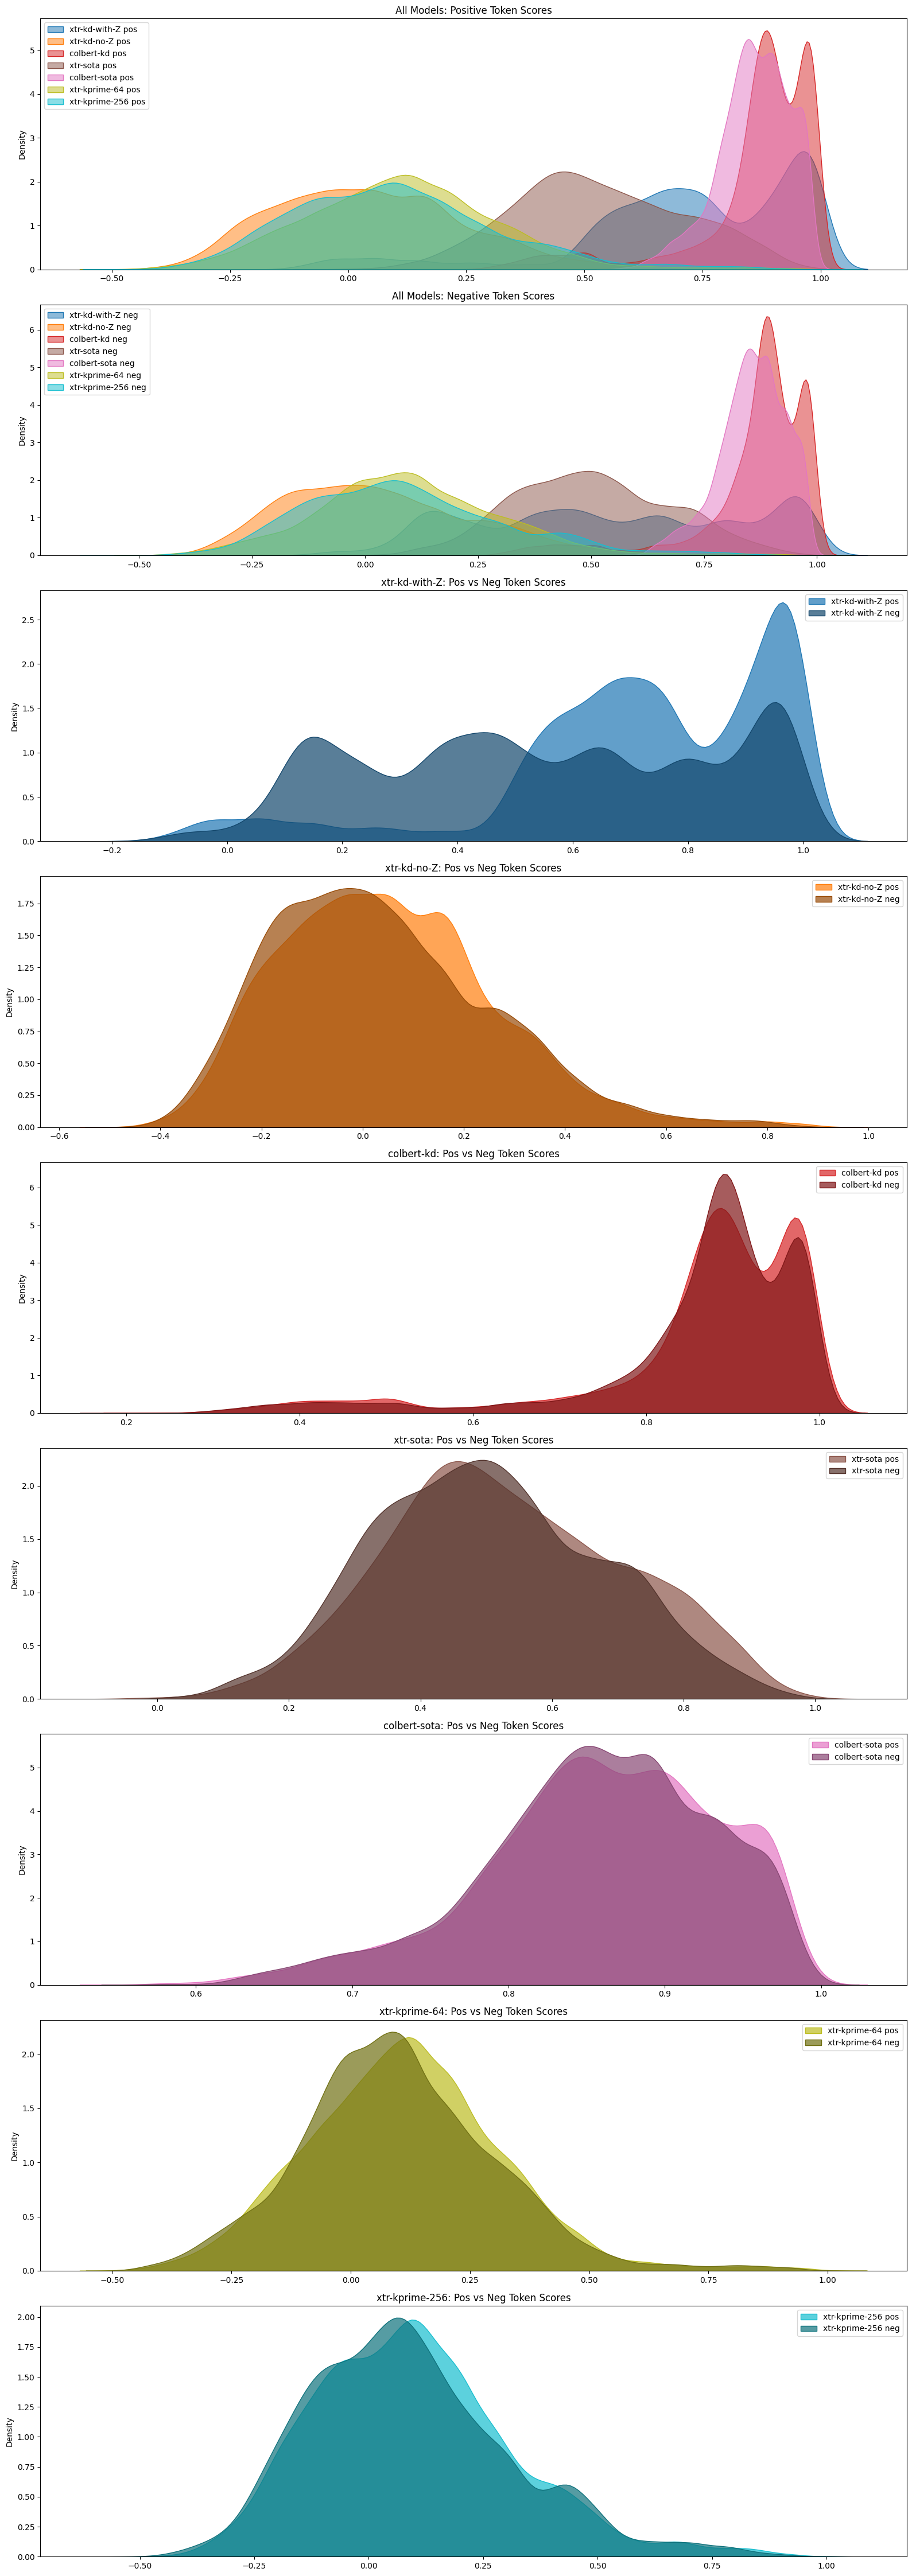

In [12]:
plot_multiple_token_score_kdes(scores, model_shortnames)

In [ ]:
plot_token_score_kdes(scores, "xtr-contrastive", "colbert-contrastive")

In [ ]:
plot_token_score_kdes(scores, "xtr-kd-with-Z", "xtr-kd-no-Z")


In [ ]:
plot_token_score_kdes(scores, "xtr-kd-with-Z", "colbert-kd")